In [ ]:
import json
import os
import base64
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from pathlib import Path
from dotenv import load_dotenv
import nest_asyncio

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

from crewai import Agent, Task, Crew, LLM
from crewai.tools import BaseTool
from pydantic import BaseModel, Field
from openai import OpenAI
from collections import Counter

In [22]:
nest_asyncio.apply()
load_dotenv()
api_key = os.getenv("OPEN_API_KEY") or os.getenv("OPENAI_API_KEY", "")
os.environ["OPENAI_API_KEY"] = api_key

DATA_DIR  = Path("../Dataset/JSON")
IMAGE_DIR = Path("../Dataset/dataset_image")

print(f"API Key Loaded: {'YES' if api_key else 'NO'}")

API Key Loaded: YES


In [23]:
label_map = {0: "Non-Sarcasm", 1: "Sarcasm"}

Records Loaded: 2409
label
0    1372
1    1037
Name: count, dtype: int64


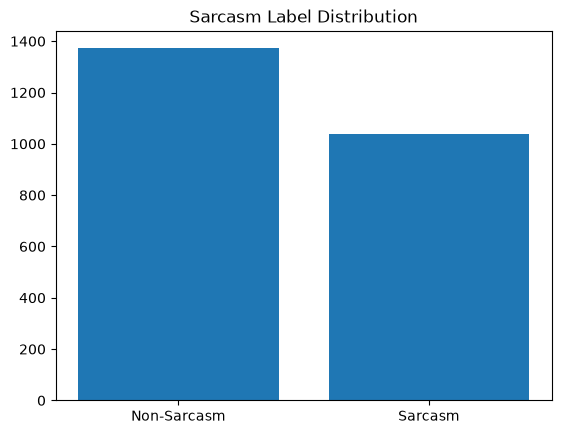

In [24]:
with open(DATA_DIR / "test.json", encoding="utf-8") as f:
    test_data = json.load(f)

df = pd.DataFrame(test_data)
print(f"Records Loaded: {len(df)}")
df.head(5)

label_dist = df["label"].value_counts().sort_index() 
print(label_dist)

x_labels = [label_map[int(idx)] for idx in label_dist.index]

plt.title("Sarcasm Label Distribution")
plt.bar(x_labels, label_dist.values)
plt.show()

In [27]:
df.isna().sum()

image_id    0
text        0
label       0
dtype: int64

In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)<[^>]+>|#?\b[a-zA-Z][a-zA-Z0-9_']+\b|\b\d+\b",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    stop_words=list(ENGLISH_STOP_WORDS),
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["text"])
terms = vectorizer.get_feature_names_out()

(2409, 2254)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11498 stored elements and shape (2409, 2254)>
  Coords	Values
  (0, 1388)	0.4011128351400205
  (0, 1230)	0.4011128351400205
  (0, 1176)	0.416704188319108
  (0, 894)	0.416704188319108
  (0, 1364)	0.3890192420685968
  (0, 1389)	0.25084831006767394
  (0, 225)	0.3415719257829347
  (1, 1047)	0.7204565717621624
  (1, 1468)	0.6935000563840726
  (2, 788)	0.5698721425513581
  (2, 1699)	0.5698721425513581
  (2, 1412)	0.5920232109367413
  (3, 1171)	0.5393562399612885
  (3, 494)	0.5191757525500572
  (3, 982)	0.4312962156031905
  (3, 1895)	0.5035225504237807
  (4, 978)	0.42721333896516656
  (4, 67)	0.16703210762841364
  (4, 899)	0.3260934163117798
  (4, 1733)	0.4987559413429004
  (4, 979)	0.46609796869580605
  (4, 86)	0.46609796869580605
  (5, 528)	0.5861825522059556
  (5, 2213)	0.5298068885049922
  (5, 1986)	0.6129393741488395
  :	:
  (2403, 1825)	0.3939822791884864
  (2403, 1853)	0.3939822791884864
  (2404, 1109)	0.3615218

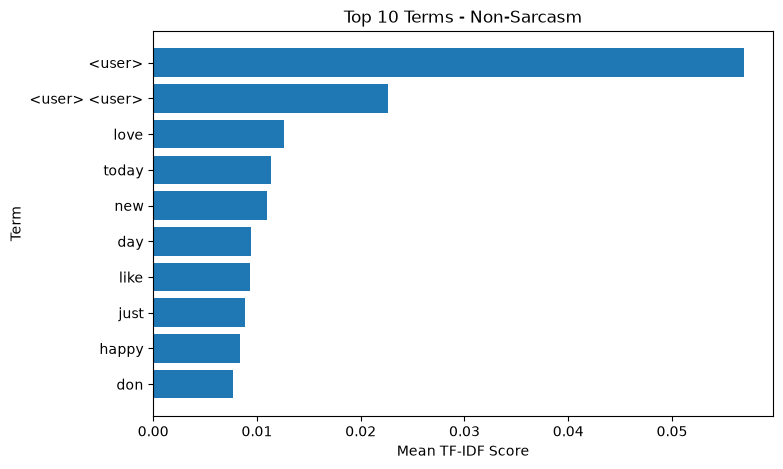

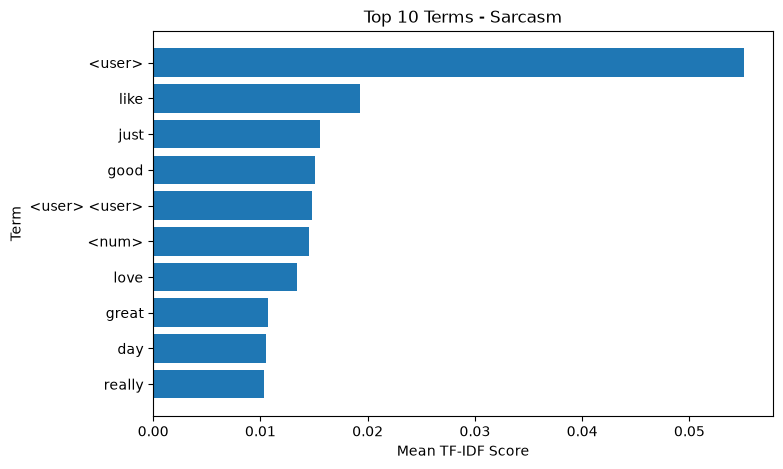

In [ ]:
def get_top_tfidf_by_label(label_value, top_n=10):
    mask = df["label"].eq(label_value).to_numpy()
    
    if mask.sum() == 0:
        print(f"No data for label {label_value}")
        return pd.DataFrame()
    
    mean_tfidf = np.asarray(X[mask].mean(axis=0)).ravel()
    
    top_idx = mean_tfidf.argsort()[::-1][:top_n]
    
    return pd.DataFrame({
        "term": terms[top_idx],
        "mean_tfidf": mean_tfidf[top_idx]
    })

for label_value in sorted(df["label"].unique()):
    top_df = get_top_tfidf_by_label(label_value, top_n=10)
    
    top_df = top_df.sort_values("mean_tfidf")
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_df["term"], top_df["mean_tfidf"])
    
    plt.xlabel("Mean TF-IDF Score")
    plt.ylabel("Term")
    plt.title(f"Top 10 Terms - {label_map.get(label_value, label_value)}")
    
    plt.show()

In [37]:
#Verify the existance of image

df["img_path"]   = df["image_id"].apply(lambda x: IMAGE_DIR / f"{x}.jpg")
df["img_exists"] = df["img_path"].apply(lambda p: p.exists())

total   = len(df)
present = int(df["img_exists"].sum())
missing = total - present

print(f"Missing Image: {missing}")

Missing Image: 0


,width,height
count,2409,2409
mean,834,811
std,264,317
min,73,65
25%,640,564
50%,800,800
75%,1072,1200
max,1200,1200



Color modes : {'RGB': 2409}
Orientations : landscape=1160  portrait=943  square=306


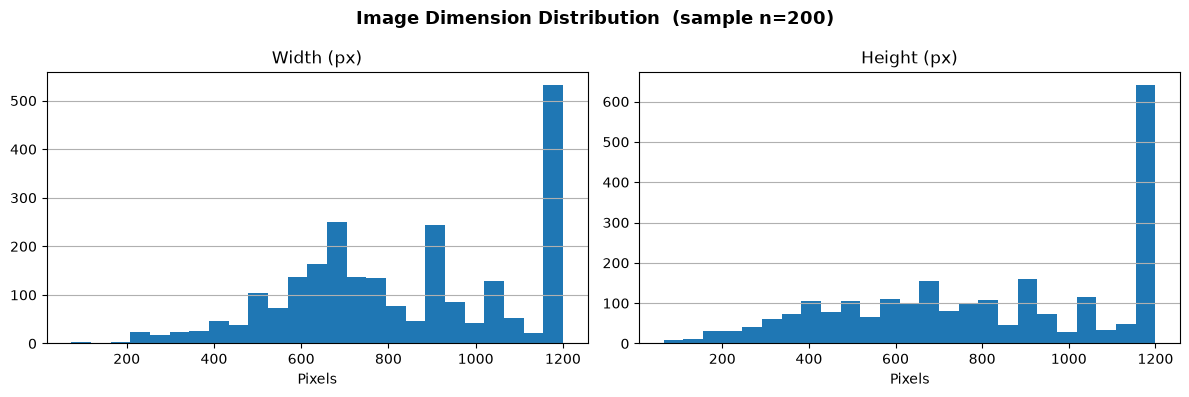

In [ ]:
stats = []
for _, row in df.iterrows():
    img = Image.open(row["img_path"])
    stats.append({"width": img.size[0], "height": img.size[1], "mode": img.mode})

df_stats = pd.DataFrame(stats)
display(df_stats[["width", "height"]].describe().round(0).astype(int))

landscape = (df_stats["width"] >  df_stats["height"]).sum()
portrait  = (df_stats["height"] > df_stats["width"]).sum()
square    = (df_stats["width"] == df_stats["height"]).sum()

#All image is rgb
print(f"\nColor modes : {df_stats['mode'].value_counts().to_dict()}")

print(f"Orientations : landscape={landscape}  portrait={portrait}  square={square}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Image Dimension Distribution  (sample n=200)", fontsize=13, fontweight="bold")
axes[0].hist(df_stats["width"],  bins=25)
axes[0].set_title("Width (px)"); axes[0].set_xlabel("Pixels"); axes[0].grid(axis="y")
axes[1].hist(df_stats["height"], bins=25)
axes[1].set_title("Height (px)"); axes[1].set_xlabel("Pixels"); axes[1].grid(axis="y")
plt.tight_layout()
plt.show()

In [44]:
openai_client = OpenAI(api_key=api_key)

class _ImageIDInput(BaseModel):
    image_id: str = Field(..., description="Post image ID (filename without .jpg extension)")


class DescribeImageTool(BaseTool):
    name: str = "describe_image"
    description: str = (
        "Loads a post image by its image_id and returns an exhaustive, position-aware "
        "visual description using GPT-4o Vision. The description includes: overall scene, "
        "every visible object with its exact spatial position, people and their expressions, "
        "any text/logos in the image, colors and lighting, and any visually ironic elements."
    )
    args_schema: type[BaseModel] = _ImageIDInput

    def _run(self, image_id: str) -> str:
        img_path = IMAGE_DIR / f"{image_id}.jpg"
        if not img_path.exists():
            return f"[ERROR] Image {image_id}.jpg not found in {IMAGE_DIR}."

        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        max_dim = 768
        if max(w, h) > max_dim:
            scale = max_dim / max(w, h)
            img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

        buf = BytesIO()
        img.save(buf, format="JPEG", quality=85)
        b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

        resp = openai_client.chat.completions.create(
            model="gpt-4o",
            messages=[{
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Describe this social media post image in exhaustive detail "
                            "for sarcasm-detection analysis. Structure your response under "
                            "these exact headings:\n\n"
                            "1. OVERALL SCENE\n"
                            "   Brief overview of what the image depicts.\n\n"
                            "2. OBJECTS & POSITIONS\n"
                            "   List EVERY visible object with its exact position in the frame "
                            "(use: top-left, top-center, top-right, middle-left, center, "
                            "middle-right, bottom-left, bottom-center, bottom-right; "
                            "and depth: foreground, midground, background).\n\n"
                            "3. PEOPLE\n"
                            "   For each person: position in frame, apparent age/gender, "
                            "facial expression, body language, clothing, apparent emotion.\n\n"
                            "4. TEXT / GRAPHICS\n"
                            "   Any text, captions, signs, logos, watermarks, or overlaid "
                            "graphics and their exact position.\n\n"
                            "5. COLORS & TONE\n"
                            "   Dominant colors, lighting quality, color temperature, "
                            "and overall visual mood.\n\n"
                            "6. IRONY / INCONGRUITY\n"
                            "   Any visually unexpected, contradictory, or ironic elements "
                            "that could signal sarcasm when paired with a caption.\n\n"
                            "Be thorough and objective. Do NOT infer sarcasm yet."
                        )
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{b64}",
                            "detail": "high"
                        }
                    }
                ]
            }],
            max_tokens=1000
        )
        return resp.choices[0].message.content


print("DescribeImageTool defined successfully")

DescribeImageTool defined successfully


In [45]:
llm = LLM(model="gpt-4o", api_key=api_key)

image_describer = Agent(
    role="Expert Visual Analyst",
    goal=(
        "Produce exhaustive, spatially-precise descriptions of social media post images "
        "that capture every visual detail relevant to sarcasm detection."
    ),
    backstory=(
        "You are a professional visual analyst specialising in multimodal social media content. "
        "You meticulously catalogue every element in an image — objects and their exact spatial "
        "positions, facial expressions, body language, text overlays, color palette, and any "
        "incongruous or ironic visual juxtapositions. Your descriptions are consumed directly by "
        "a sarcasm classifier, so you pay special attention to unexpected visual elements and any "
        "mismatch between what the image portrays and what a caption might imply."
    ),
    tools=[DescribeImageTool()],
    llm=llm,
    verbose=True,
    allow_delegation=False,
)

sarcasm_classifier = Agent(
    role="Multimodal Sarcasm Detection Specialist",
    goal=(
        "Accurately classify social media posts as SARCASM or NOT SARCASM by analysing "
        "the semantic alignment — or misalignment — between the post caption and its image."
    ),
    backstory=(
        "You are an expert in computational sarcasm and irony detection with deep knowledge of "
        "how sarcasm operates across text and visual modalities. You look for: "
        "(1) semantic gaps between what the image shows and what the caption says, "
        "(2) verbal irony, hyperbole, or understatement in the text, "
        "(3) incongruous visual-textual juxtapositions, "
        "(4) cultural or contextual cues that invert the literal reading. "
        "You always produce a structured verdict with a clear LABEL and evidence-based reasoning "
        "that cites specific elements from both the caption and the image description."
    ),
    tools=[],
    llm=llm,
    verbose=True,
    allow_delegation=False,
)

print("Agents initialised successfully.")

Agents initialised successfully.


In [46]:
async def classify_post(image_id: str, caption: str) -> dict:
    describe_task = Task(
        description=(
            f"Use the describe_image tool to generate a detailed visual description "
            f"for the post with image_id='{image_id}'. "
            f"Cover ALL objects with exact spatial positions, all visible text, "
            f"people, colors, and any ironic visual elements."
        ),
        expected_output=(
            "A structured description under six headings: OVERALL SCENE, "
            "OBJECTS & POSITIONS, PEOPLE, TEXT/GRAPHICS, COLORS & TONE, "
            "and IRONY/INCONGRUITY."
        ),
        agent=image_describer,
    )

    classify_task = Task(
        description=(
            f"You are given a social media post to classify:\n\n"
            f"  CAPTION: \"{caption}\"\n\n"
            f"The detailed image description is available in your context "
            f"(output of the previous task).\n\n"
            f"Analyse the relationship between the caption and the image. "
            f"Determine whether the post is sarcastic.\n\n"
            f"Respond in EXACTLY this format:\n"
            f"LABEL: <SARCASM or NOT SARCASM>\n"
            f"CONFIDENCE: <High / Medium / Low>\n"
            f"REASON: <2-4 sentences citing specific visual elements from the image "
            f"description and specific words or phrases from the caption>"
        ),
        expected_output="Three lines: LABEL, CONFIDENCE, and REASON.",
        agent=sarcasm_classifier,
        context=[describe_task],
    )

    crew = Crew(
        agents=[image_describer, sarcasm_classifier],
        tasks=[describe_task, classify_task],
        verbose=False,
    )

    result     = await crew.kickoff_async()
    raw_output = str(result)

    label, confidence, reason = "UNKNOWN", "UNKNOWN", raw_output
    for line in raw_output.splitlines():
        ls = line.strip()
        if ls.upper().startswith("LABEL:"):
            label = ls.split(":", 1)[1].strip().upper()
        elif ls.upper().startswith("CONFIDENCE:"):
            confidence = ls.split(":", 1)[1].strip()
        elif ls.upper().startswith("REASON:"):
            reason = ls.split(":", 1)[1].strip()

    pred_label = 1 if ("SARCASM" in label and "NOT" not in label) else 0

    return {
        "image_id"  : image_id,
        "caption"   : caption,
        "pred_label": pred_label,
        "label_text": label,
        "confidence": confidence,
        "reason"    : reason,
        "raw_output": raw_output,
    }

print("classify_post() ready (async).")

classify_post() ready (async).


In [52]:
#Sample 100 Sarcasm and 100 Non-Sarcasm Data

N_PER_CLASS = 100
RANDOM_SEED = 42

sarc_sample     = df[df["label"] == 1].sample(N_PER_CLASS, random_state=RANDOM_SEED)
non_sarc_sample = df[df["label"] == 0].sample(N_PER_CLASS, random_state=RANDOM_SEED)
sample_df = (pd.concat([sarc_sample, non_sarc_sample])
               .sample(frac=1, random_state=RANDOM_SEED)
               .reset_index(drop=True))

print(f"Balanced sample: {N_PER_CLASS} sarcasm, {N_PER_CLASS} non-sarcasm")
print(f"{sample_df['label'].value_counts().to_dict()}")

Balanced sample: 100 sarcasm, 100 non-sarcasm
{1: 100, 0: 100}


In [ ]:
results = []
TOTAL = len(sample_df)

for i, row in sample_df.iterrows():
    sep = "=" * 60
    print(f"\n{sep}")
    print(f"[{i+1}/{TOTAL}]  image_id = {row['image_id']}")
    print(f"Caption   : {row['text']}")
    print(f"True label: {'SARCASM' if row['label'] == 1 else 'NOT SARCASM'}")
    print(sep)

    try:
        res = await classify_post(str(row["image_id"]), row["text"])
        res["true_label"] = int(row["label"])
        results.append(res)
        print(f"\n  -> Predicted : {res['label_text']}  [{res['confidence']}]")
        print(f"     Reason    : {res['reason'][:160]}...")
    except Exception as exc:
        print(f"  [ERROR] {exc}")
        results.append({
            "image_id"  : str(row["image_id"]),
            "caption"   : row["text"],
            "pred_label": -1,
            "label_text": "ERROR",
            "confidence": "N/A",
            "reason"    : str(exc),
            "raw_output": str(exc),
            "true_label": int(row["label"]),
        })

df_results = pd.DataFrame(results)
df_results.to_csv("crewai_results.csv", index=False)
print(f"Pipeline complete")

In [ ]:
valid = df_results[df_results["pred_label"].isin([0, 1])]
if len(valid) > 0:
    correct = (valid["pred_label"] == valid["true_label"]).sum()
    acc     = correct / len(valid)
    print(f"\n{'='*65}")
    print(f"Sample accuracy  : {correct}/{len(valid)}  ({acc:.1%})")
    print(f"{'='*65}")

    breakdown = Counter()
    for _, r in valid.iterrows():
        t = "S" if r["true_label"] == 1 else "N"
        p = "S" if r["pred_label"] == 1 else "N"
        breakdown[f"True={t} Pred={p}"] += 1
    print("\nPrediction breakdown:")
    for k, v in sorted(breakdown.items()):
        print(f"  {k} : {v}")

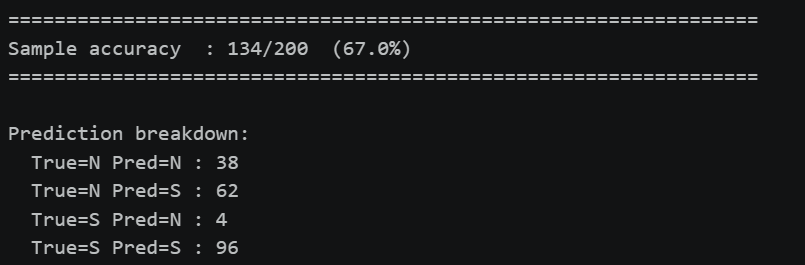